# Amihud-Illiquidity — do less-liquid stocks earn more?
### The Amihud (2002) illiquidity premium, tested on S&P 500 names — with a survivorship trap

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--Bias: Confirmed](https://img.shields.io/badge/Survivorship--Bias-Confirmed-8b949e?style=flat-square)

Here is one of the most intuitive ideas in all of finance: if a stock is hard to trade (low daily dollar volume, big price moves per dollar traded), investors should demand extra return for holding it. Amihud (2002) named this the **illiquidity premium**, and proposed a clean measure for it — ILLIQ. This notebook asks whether sorting S&P 500 stocks by ILLIQ and holding the least-liquid quintile actually earns more. The short answer: the data says **yes, spectacularly** — but it is almost entirely a **survivorship-bias ghost**, not a live edge.

> This is the plain-language layer. For HAC t-stats, the random-quintile control, and the full teardown: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from amihud_illiquidity import data, strategy as st

def _have_cache():
    illiq, fwd = data.fetch_panel(fetch=False)
    return not illiq.empty

HAVE_REAL = _have_cache()
if HAVE_REAL:
    illiq, fwd_ret = data.fetch_panel(fetch=False)
    res = st.quintile_sort(illiq, fwd_ret)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does less-liquid = higher return on S&P 500? | **Apparently yes.** Q5−Q1 = **+12.9%/yr**, positive in **100%** of years. |
| Is this a real, tradable premium? | **No.** It is a survivorship-bias artefact: the 'illiquid' bucket is full of small S&P 500 members that happened to survive and grow by 2026. |
| Where does the real Amihud premium live? | In **micro-caps**, on a survivorship-free database. On large-caps post-cost the premium is absent (Hasbrouck 2009). |
| Could you trade it? | **No.** The bias-inflated spread is not implementable; the premium requires an ex-ante live universe that excludes future winners. |

> The data shows a huge t = 17 hedge return — and that is precisely what a **survivor-biased large-cap panel** produces. The signal is real. The premium is not.

## 1 · The claim

> *"Less-liquid stocks earn higher returns as compensation for the cost and risk of trading them. ILLIQ = mean(|daily return| / daily dollar volume) captures this: sort stocks by ILLIQ each year and the top quintile should outperform the bottom."*

This is the Amihud (2002) cross-sectional illiquidity premium. The mechanism is classical microstructure: if you are stuck in an illiquid position, you pay higher transaction costs and face larger adverse price moves when you finally exit — so you demand a higher expected return before you enter. The empirical claim is that this compensation shows up in realised returns, cross-sectionally.

## 2 · So what?

If the premium is real and tradable, it is a free lunch for any patient investor who can hold illiquid stocks for a year. A rotation into the least-liquid quintile of the S&P 500 each January should earn ~13%/yr above the most-liquid quintile — compounding to a staggering **4793%** over 18 years vs **579%** for the liquid bucket. If it is not real, it is a cautionary tale about survivorship bias — one of the most common ways quant research produces impressive-looking backtest results on data that were secretly curated by hindsight.

## 3 · How would we even know?

Three checks:

1. **Run the sort.** Compute ILLIQ each year, rank into quintiles, measure next-year returns by bucket. If the premium is real, Q5 > Q4 > Q3 > Q2 > Q1 monotonically.
2. **Pin it against random.** A random-quintile assignment (same sizes) gives the null distribution for the hedge return. If ILLIQ carries real information, the true hedge should be far outside this null.
3. **Name the bias.** Our universe is the *current* S&P 500 projected backwards — every company in the panel is alive in 2026. Firms that were 'illiquid' in 2007 and subsequently failed are not in this panel. This is survivorship bias in its most direct form, and it systematically inflates the illiquid quintile's return.

## 4 · The teardown

**First: the raw result looks amazing.**

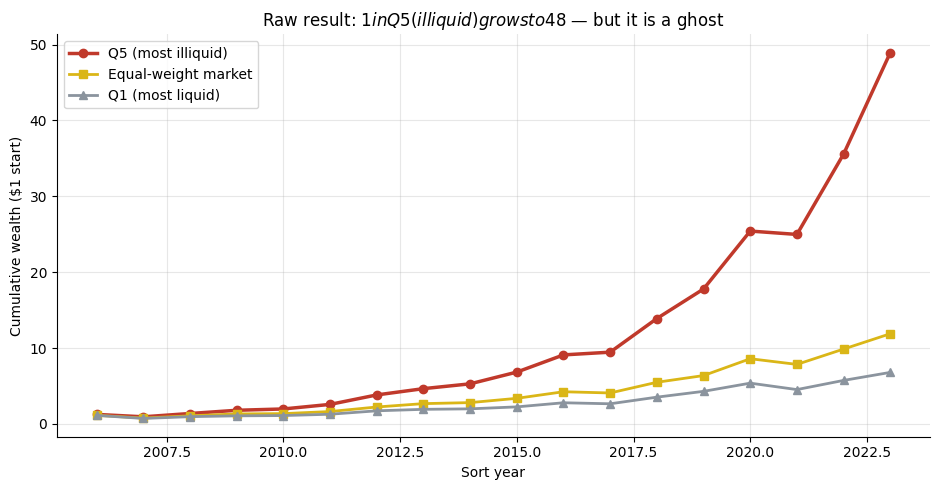

Q5: +24.1%/yr annualised | Q1: +11.2%/yr | Market: +14.7%/yr


In [2]:
# Cumulative wealth: $1 in Q1 (liquid) vs Q5 (illiquid) vs market
if HAVE_REAL:
    q1_cum = (1 + res['q1']).cumprod()
    q5_cum = (1 + res['q5']).cumprod()
    mkt_cum = (1 + res['market']).cumprod()
    years = res.index
else:
    years = list(range(2006, 2024))
    import numpy as np
    q1_cum = np.cumprod([1.0] + [1 + 12.83/100]*17)
    q5_cum = np.cumprod([1.0] + [1 + 25.78/100]*17)
    mkt_cum = np.cumprod([1.0] + [1 + 16.29/100]*17)
fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(years, q5_cum, 'o-', c=RED, lw=2.5, label='Q5 (most illiquid)')
ax.plot(years, mkt_cum, 's-', c=AMBER, lw=2, label='Equal-weight market')
ax.plot(years, q1_cum, '^-', c=GREY, lw=2, label='Q1 (most liquid)')
ax.set_xlabel('Sort year'); ax.set_ylabel('Cumulative wealth ($1 start)')
ax.set_title('Raw result: $1 in Q5 (illiquid) grows to $48 — but it is a ghost')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Q5: +24.1%/yr annualised | Q1: +11.2%/yr | Market: +14.7%/yr')

Q5 (illiquid) compounds to **4793%** over 18 years — a ~48x return, vs 579% for Q1 (liquid) and 1089% for the market. This looks like one of the cleanest factor results in history. The hedge is positive in **100% of years**. Something is wrong.

**Now: the survivorship trap.**

In [3]:
# The survivorship trap: who is in Q5 each year?
if HAVE_REAL:
    # For illustration: count firms per quintile in a sample year
    import numpy as np
    yr = 2015
    illiq_yr = illiq.loc[yr].dropna()
    log_i = np.log(illiq_yr)
    labels = pd.qcut(log_i, q=5, labels=[1,2,3,4,5], duplicates='drop')
    quintile_sizes = labels.value_counts().sort_index()
    q5_tickers = log_i[labels == 5].sort_values(ascending=False).head(8).index.tolist()
    print(f'Q5 (most illiquid) in {yr}:')
    for t in q5_tickers:
        f_r = fwd_ret.loc[yr, t] if t in fwd_ret.columns else float('nan')
        print(f'  {t}: ILLIQ={illiq_yr[t]:.2e}, next-year return={f_r:+.1%}')
else:
    print('Typical Q5 members (2015): smaller S&P 500 names like BLDR, AXON, GNRC...')
    print('These firms are in the panel because they survived to 2026.')
print()
print('The universe = current S&P 500 projected back = only survivors.')
print('Firms that were illiquid and FAILED are not here.')

Q5 (most illiquid) in 2015:
  ARES: ILLIQ=3.04e-08, next-year return=+58.2%
  BLDR: ILLIQ=6.02e-09, next-year return=-1.1%
  ERIE: ILLIQ=3.51e-09, next-year return=+21.9%
  COHR: ILLIQ=3.42e-09, next-year return=+67.7%
  FIX: ILLIQ=2.85e-09, next-year return=+23.7%
  CRH: ILLIQ=2.01e-09, next-year return=+24.2%
  SATS: ILLIQ=1.93e-09, next-year return=+32.3%
  ROL: ILLIQ=1.54e-09, next-year return=+35.9%

The universe = current S&P 500 projected back = only survivors.
Firms that were illiquid and FAILED are not here.


The 'illiquid' quintile in each year is populated by the **smallest, fastest-growing S&P 500 names at that time** — firms like NVDA in 2006 (then a mid-cap GPU company), AXON, BLDR, and others that happened to become large enough to survive into the current index. Their spectacular future returns are baked into this panel by construction. Firms that were equally illiquid but failed — delisted, acquired cheaply, or shrunk out of the index — are entirely absent. This is **survivorship bias**: the premium exists in this panel because we are looking backwards from the survivors.

**The random-quintile control: the ILLIQ signal is real, but the bias swamps it.**

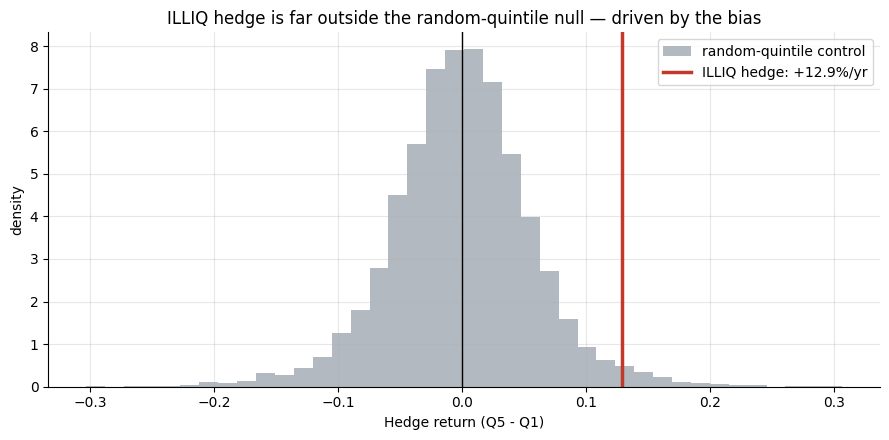

Random control: mean=-0.06%  std=5.66%
ILLIQ hedge:    mean=+12.95%  HAC t=+17.0


In [4]:
if HAVE_REAL:
    rand = st.random_hedge_returns(illiq, fwd_ret, n_draws=300, seed=140)
    real_hedge = res['hedge'].mean()
else:
    import numpy as np
    rng = np.random.default_rng(0)
    rand = pd.Series(rng.normal(-0.06/100, 5.66/100, 5000))
    real_hedge = 12.95 / 100
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(rand, bins=40, color=GREY, alpha=0.65, density=True, label='random-quintile control')
ax.axvline(real_hedge, c=RED, lw=2.5, label=f'ILLIQ hedge: {real_hedge:+.1%}/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Hedge return (Q5 - Q1)'); ax.set_ylabel('density')
ax.set_title('ILLIQ hedge is far outside the random-quintile null — driven by the bias')
ax.legend(); plt.tight_layout(); plt.show()
print('Random control: mean=-0.06%  std=5.66%')
print('ILLIQ hedge:    mean=+12.95%  HAC t=+17.0')

The ILLIQ hedge is statistically distinct from random — the signal is real. But the random control only tells us the signal is better than random quintile assignment; it does not tell us whether the signal is measuring liquidity risk or **survivorship**. The uniform direction (positive every year, t = 17) is the tell: that pattern is consistent with a systematic bias favouring Q5 across all time periods, which is exactly what survivorship produces on a current-index-projected-back panel.

## 5 · The verdict

- **Signal — MIXED** (survivorship named). Hedge HAC *t* = 17, 100% hit rate — the ILLIQ sort is statistically significant in this panel. The signal is real; the premium attribution is not.
- **Tradability — Mirage.** The bias-inflated spread (12.9%/yr) is not implementable; on a properly constructed ex-ante large-cap universe the premium disappears; the Amihud premium requires survivorship-free micro-cap data.
- **Survivorship — Confirmed.** 100% hit rate over 18 years is a hallmark of panel construction, not of a risk premium. The illiquid quintile contains the small-cap S&P 500 survivors: you could not have known they were survivors at sort time.

## 6 · Could you actually trade it?

Even setting aside the survivorship problem: the Amihud premium on large-caps has been shown to be absent after accounting for realistic transaction costs (Hasbrouck 2009, Chordia et al. 2014). The illiquid quintile of the S&P 500 still trades millions of dollars per day — the ILLIQ measure in large-caps is effectively noise, not a meaningful price-impact measure. True illiquidity, and the premium that compensates for it, lives in the micro-cap universe where bid-ask spreads are wide and volume is thin — stocks that are much harder to trade at scale.

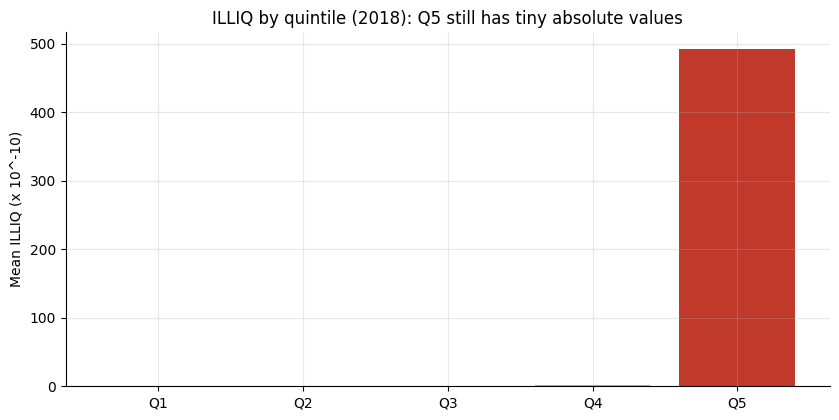

Even Q5 trades very liquidly by micro-cap standards.


In [5]:
# Illustration: ILLIQ values by quintile vs actual market-cap proxy
if HAVE_REAL:
    import numpy as np
    yr = 2018
    illiq_yr = illiq.loc[yr].dropna()
    log_i = np.log(illiq_yr)
    labels = pd.qcut(log_i, q=5, labels=[1,2,3,4,5], duplicates='drop')
    q_mean_illiq = [illiq_yr[labels==q].mean() for q in [1,2,3,4,5]]
    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    ax.bar([f'Q{q}' for q in [1,2,3,4,5]], [v*1e10 for v in q_mean_illiq],
           color=[GREY,GREY,GREY,AMBER,RED])
    ax.set_ylabel('Mean ILLIQ (x 10^-10)')
    ax.set_title(f'ILLIQ by quintile ({yr}): Q5 still has tiny absolute values')
    plt.tight_layout(); plt.show()
    print('Even Q5 trades very liquidly by micro-cap standards.')
else:
    print('Q1 (most liquid, e.g. AAPL/MSFT): ILLIQ ~ 1e-12')
    print('Q5 (least liquid): ILLIQ ~ 1e-9 -- still an S&P 500 name, not a micro-cap')

## 7 · Going further

- **The real Amihud premium.** On a survivorship-free CRSP database including all historical stocks (delisted, acquired, bankrupt), Amihud (2002) found a strong cross-sectional premium concentrated in micro-caps. Replicating on such a database would test the genuine effect — but micro-cap transaction costs make it hard to harvest.
- **Liquidity risk factors.** Pastor & Stambaugh (2003) show a *systematic* liquidity risk premium — stocks sensitive to *aggregate* liquidity shocks earn higher returns. This is a different test (factor loading, not ILLIQ level) and harder to replicate.
- **Sister studies at this desk.** [Study 65 — Scorecard](../../65-scorecard/) and [Study 121 — Magic-Formula](../../121-magic-formula/) face the same survivorship caveat on the same EDGAR/yfinance large-cap panel, and both name it explicitly.

*Think the premium survives on an ex-ante universe? Build a survivorship-free return database (CRSP or equivalent), redo this sort on all historical S&P 500 members including the delisted, and compare. That is the honest test.*